[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Y-Robin/DeepLearningKurs/blob/main/notebooks/Day_1/01_tag_1_daten_samples_ausreisser_korrelation.ipynb)

# Tag 1 - 01 Daten, Samples, Ausreißer und Korrelation

Dieses Notebook bleibt bewusst bei Daten. Noch keine Modelle, keine Loss-Funktion, keine Hyperparameter. Es passt zu den Folien **Eingangsdaten** und bereitet **überwachtes Lernen** nur über `X` und `y` vor.


## Was du hier testen kannst

- Einzelwert, 1D-Signal, 2D-Bild und 3D/RGB-Bild als unterschiedliche Sample-Formen.
- Tabellen mit `X` und `y`.
- Ausreißer sichtbar machen.
- Korrelationen anschauen, ohne schon ein Modell zu trainieren.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
print('Setup abgeschlossen.')


Setup abgeschlossen.


## Ein Sample kann verschiedene Formen haben

Wichtig ist nicht die Optik, sondern die Form: Ein Modell bekommt pro Sample Zahlen. Diese Zahlen können ein einzelner Wert, ein Vektor, ein Signal, ein Bild oder ein mehrdimensionales Array sein.


,Sample-Typ,Form,Beispiel
0,einzelner Wert,"(1,)",ein Messwert
1,1D-Signal,"(80,)",Zeitreihe/Rohsignal
2,2D-Graustufenbild,"(8, 8)",Graustufenbild
3,3D/RGB-Bild,"(8, 8, 3)",Farbbild


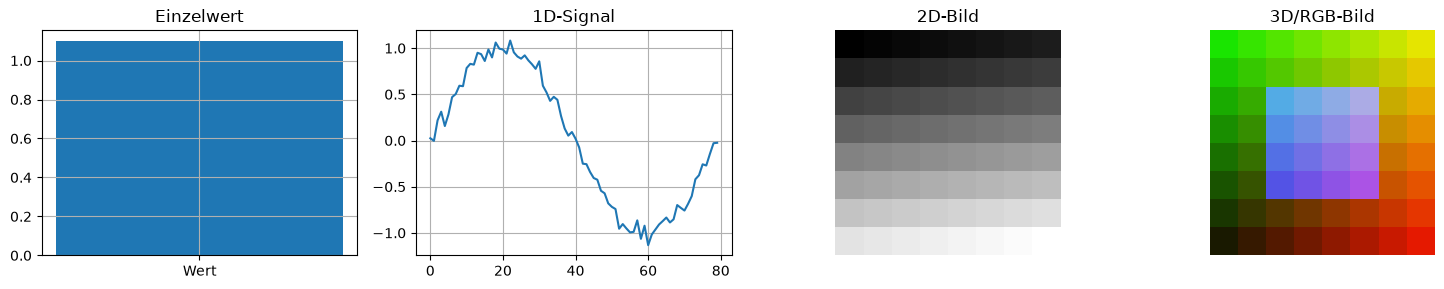

In [2]:
scalar_sample = np.array([1.1])
signal_1d = np.sin(np.linspace(0, 2 * np.pi, 80)) + rng.normal(0, 0.08, 80)
image_2d = np.arange(64).reshape(8, 8)
image_rgb = np.zeros((8, 8, 3))
image_rgb[:, :, 0] = np.linspace(0.1, 0.9, 8)
image_rgb[:, :, 1] = np.linspace(0.9, 0.1, 8)[:, None]
image_rgb[2:6, 2:6, 2] = 0.9

display(pd.DataFrame({
    'Sample-Typ': ['einzelner Wert', '1D-Signal', '2D-Graustufenbild', '3D/RGB-Bild'],
    'Form': [scalar_sample.shape, signal_1d.shape, image_2d.shape, image_rgb.shape],
    'Beispiel': ['ein Messwert', 'Zeitreihe/Rohsignal', 'Graustufenbild', 'Farbbild'],
}))

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].bar(['Wert'], scalar_sample)
axes[0].set_title('Einzelwert')
axes[1].plot(signal_1d)
axes[1].set_title('1D-Signal')
axes[2].imshow(image_2d, cmap='gray')
axes[2].set_title('2D-Bild')
axes[2].axis('off')
axes[3].imshow(image_rgb)
axes[3].set_title('3D/RGB-Bild')
axes[3].axis('off')
plt.tight_layout()
plt.show()


## Tabellarische Daten: `X` und `y`

Jede Zeile ist ein Sample. Die Eingangsdaten stehen in `X`, das Label oder die Zielgröße in `y`.


In [3]:
housing_df = pd.DataFrame({
    'Wohnflaeche_qm': [42, 55, 73, 88, 104, 126, 65, 94],
    'Zimmer': [1, 2, 3, 3, 4, 5, 2, 4],
    'Entfernung_Zentrum_km': [1.2, 8.5, 4.0, 11.0, 6.5, 14.0, 3.5, 10.5],
    'Monatsmiete_EUR': [850, 940, 1290, 1370, 1660, 1840, 1180, 1480],
})
X = housing_df[['Wohnflaeche_qm', 'Zimmer', 'Entfernung_Zentrum_km']]
y = housing_df['Monatsmiete_EUR']
display(housing_df)
print('X:', X.shape)
print('y:', y.shape)


,Wohnflaeche_qm,Zimmer,Entfernung_Zentrum_km,Monatsmiete_EUR
0,42,1,1.2,850
1,55,2,8.5,940
2,73,3,4.0,1290
3,88,3,11.0,1370
4,104,4,6.5,1660
5,126,5,14.0,1840
6,65,2,3.5,1180
7,94,4,10.5,1480


X: (8, 3)
y: (8,)


## Interaktiv: Rohdaten, Rauschen und Ausreißer

Das ist noch kein Modell. Es geht nur darum, wie Daten aussehen können und warum Ausreißer später Modelle und Metriken beeinflussen.


In [4]:
def raw_data_demo(samples=80, rauschen=0.7, ausreisser=4, ausreisser_staerke=8.0):
    local_rng = np.random.default_rng(RANDOM_STATE)
    x_values = np.linspace(-3, 3, samples)
    y_clean = 1.8 * x_values - 0.5
    y_values = y_clean + local_rng.normal(0, rauschen, samples)
    outlier_idx = np.array([], dtype=int)
    if ausreisser > 0:
        outlier_idx = local_rng.choice(samples, size=min(ausreisser, samples), replace=False)
        y_values[outlier_idx] += ausreisser_staerke

    plt.scatter(x_values, y_values, alpha=0.75, label='Rohdaten')
    if len(outlier_idx):
        plt.scatter(x_values[outlier_idx], y_values[outlier_idx], color='red', s=80, label='Ausreißer')
    plt.plot(x_values, y_clean, color='green', linestyle='--', label='zugrunde liegender Trend')
    plt.xlabel('Feature x')
    plt.ylabel('Zielgröße y')
    plt.title('Rohdaten mit Rauschen und Ausreißern')
    plt.legend()
    plt.show()

widgets.interact(
    raw_data_demo,
    samples=widgets.IntSlider(value=80, min=30, max=200, step=10),
    rauschen=widgets.FloatSlider(value=0.7, min=0.0, max=3.0, step=0.1),
    ausreisser=widgets.IntSlider(value=4, min=0, max=20),
    ausreisser_staerke=widgets.FloatSlider(value=8.0, min=-15.0, max=20.0, step=0.5),
);


interactive(children=(IntSlider(value=80, description='samples', max=200, min=30, step=10), FloatSlider(value=…

## Korrelation ist Datenanalyse, kein Modell

Korrelationen zeigen lineare Zusammenhänge zwischen Spalten. Sie beweisen keine Ursache und ersetzen kein Modell, sind aber ein guter erster Blick auf die Daten.


In [5]:
def make_housing_data(n=160, seed=RANDOM_STATE):
    local_rng = np.random.default_rng(seed)
    wohnflaeche = local_rng.uniform(28, 155, n)
    zimmer = np.clip(np.round(wohnflaeche / 32 + local_rng.normal(0, 0.6, n)), 1, 6)
    entfernung = local_rng.uniform(0.5, 18.0, n)
    alter = local_rng.uniform(0, 80, n)
    miete = 320 + 10.5 * wohnflaeche + 115 * zimmer - 24 * entfernung - 2.0 * alter + local_rng.normal(0, 90, n)
    return pd.DataFrame({
        'Wohnflaeche_qm': wohnflaeche,
        'Zimmer': zimmer,
        'Entfernung_Zentrum_km': entfernung,
        'Gebaeudealter_Jahre': alter,
        'Monatsmiete_EUR': miete,
    })

data_df = make_housing_data()
display(data_df.head())
display(data_df.corr(numeric_only=True).round(2))


,Wohnflaeche_qm,Zimmer,Entfernung_Zentrum_km,Gebaeudealter_Jahre,Monatsmiete_EUR
0,126.292418,5.0,5.542723,45.261752,2039.923795
1,83.737562,2.0,13.360630,56.160174,948.258211
2,137.041936,4.0,4.042080,51.835879,1981.211191
3,116.565740,3.0,12.658967,52.194645,1603.373601
4,39.960523,1.0,15.562584,25.297132,336.836476


,Wohnflaeche_qm,Zimmer,Entfernung_Zentrum_km,Gebaeudealter_Jahre,Monatsmiete_EUR
Wohnflaeche_qm,1.00,0.88,-0.06,0.02,0.94
Zimmer,0.88,1.00,-0.10,0.01,0.90
Entfernung_Zentrum_km,-0.06,-0.10,1.00,0.13,-0.29
Gebaeudealter_Jahre,0.02,0.01,0.13,1.00,-0.09
Monatsmiete_EUR,0.94,0.90,-0.29,-0.09,1.00


In [ ]:
def correlation_plot(feature='Wohnflaeche_qm'):
    corr = data_df[[feature, 'Monatsmiete_EUR']].corr().iloc[0, 1]
    plt.scatter(data_df[feature], data_df['Monatsmiete_EUR'], alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel('Monatsmiete_EUR')
    plt.title(f'{feature} vs. Miete | Korrelation={corr:.2f}')
    plt.show()

widgets.interact(
    correlation_plot,
    feature=widgets.Dropdown(
        options=['Wohnflaeche_qm', 'Zimmer', 'Entfernung_Zentrum_km', 'Gebaeudealter_Jahre'],
        value='Wohnflaeche_qm',
    ),
);


interactive(children=(Dropdown(description='feature', options=('Wohnflaeche_qm', 'Zimmer', 'Entfernung_Zentrum…

## Klassenverteilungen und Merkmale

Bei Klassifikationsdaten ist `y` eine Kategorie. Bevor ein Modell trainiert wird, lohnt sich ein Blick auf Klassenverteilung, einzelne Merkmale und Feature-Kombinationen.


In [7]:
def make_quality_data_for_inspection(n_ok=160, n_fehler=70, overlap=0.35, seed=RANDOM_STATE):
    local_rng = np.random.default_rng(seed)
    ok = local_rng.normal(loc=[0.25, 0.35], scale=[0.18 + overlap * 0.15, 0.20 + overlap * 0.15], size=(n_ok, 2))
    fehler = local_rng.normal(loc=[0.95, 0.95], scale=[0.20 + overlap * 0.16, 0.22 + overlap * 0.16], size=(n_fehler, 2))
    X_values = np.vstack([ok, fehler])
    y_values = np.r_[np.zeros(n_ok, dtype=int), np.ones(n_fehler, dtype=int)]
    order = local_rng.permutation(len(y_values))
    return pd.DataFrame(X_values[order], columns=['Vibration', 'Temperaturabweichung']).assign(Fehlerhaft=y_values[order])

classification_df = make_quality_data_for_inspection()
X_classification = classification_df[['Vibration', 'Temperaturabweichung']]
y_classification = classification_df['Fehlerhaft']
display(classification_df.head())
display(y_classification.value_counts().rename(index={0: 'OK', 1: 'Fehlerhaft'}).to_frame('Anzahl'))
print('X:', X_classification.shape)
print('y:', y_classification.shape)


,Vibration,Temperaturabweichung,Fehlerhaft
0,0.683621,1.081016,1
1,0.897479,0.397028,1
2,0.776364,1.156844,1
3,0.375112,0.687693,0
4,0.167169,0.536223,0


,Anzahl
Fehlerhaft,
OK,160
Fehlerhaft,70


X: (230, 2)
y: (230,)


In [ ]:
def classification_data_explorer(feature='Vibration', overlap=0.35, fehlerhafte_samples=70):
    df = make_quality_data_for_inspection(n_fehler=fehlerhafte_samples, overlap=overlap)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    counts = df['Fehlerhaft'].value_counts().sort_index()
    axes[0].bar(['OK', 'Fehlerhaft'], [counts.get(0, 0), counts.get(1, 0)], color=['#4c78a8', '#e45756'])
    axes[0].set_title('Klassenverteilung')
    axes[0].set_ylabel('Samples')

    for label, name, color in [(0, 'OK', '#4c78a8'), (1, 'Fehlerhaft', '#e45756')]:
        part = df[df['Fehlerhaft'] == label]
        axes[1].hist(part[feature], bins=24, alpha=0.55, label=name, color=color)
    axes[1].set_title(f'1D-Verteilung: {feature}')
    axes[1].legend()

    for label, name, color in [(0, 'OK', '#4c78a8'), (1, 'Fehlerhaft', '#e45756')]:
        part = df[df['Fehlerhaft'] == label]
        axes[2].scatter(part['Vibration'], part['Temperaturabweichung'], alpha=0.65, label=name, color=color)
    axes[2].set_xlabel('Vibration')
    axes[2].set_ylabel('Temperaturabweichung')
    axes[2].set_title('2D-Rohdaten')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

widgets.interact(
    classification_data_explorer,
    feature=widgets.Dropdown(options=['Vibration', 'Temperaturabweichung'], value='Vibration'),
    overlap=widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.05),
    fehlerhafte_samples=widgets.IntSlider(value=70, min=10, max=160, step=10),
);


interactive(children=(Dropdown(description='feature', options=('Vibration', 'Temperaturabweichung'), value='Vi…